# Day 42 — Other Clustering Algorithms & Gaussian Mixture Models

- Understand Agglomerative Clustering, BIRCH, Mean-Shift, and Spectral Clustering.
- Know when alternatives to K-Means are useful.
- Understand Gaussian Mixture Models (GMMs).
- Understand hard vs. soft clustering.
- Understand GMM covariance types.
- Understand the Expectation-Maximization (EM) idea.
- Use `predict_proba()` for soft assignments.
- Use `score_samples()` for probability-density analysis.
- Compare GMM models using AIC and BIC.


## 1. Setup

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    Birch,
    MeanShift,
    SpectralClustering
)
from sklearn.mixture import GaussianMixture

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


# 3. Clustering Algorithm Map — The Big Picture

Clustering algorithms make different assumptions about what a "cluster" looks like.

A useful way to choose an algorithm is to ask four questions:

1. **Shape:** Are clusters spherical, elongated, or curved?
2. **Density:** Are clusters defined by dense regions?
3. **Scale:** Is the dataset small or extremely large?
4. **Assignment:** Do we need a hard label or a probability?

### A practical mental map

| Family | Algorithms | Main idea |
|---|---|---|
| Centroid-based | K-Means | Points are close to a center |
| Hierarchical | Agglomerative | Build a hierarchy by merging clusters |
| Density-based | Mean-Shift | Find dense regions / modes |
| Scalable hierarchical | BIRCH | Compress data into a CF tree |
| Graph-based | Spectral | Use connectivity between observations |
| Probabilistic | GMM | Data comes from Gaussian components |

**Important:** There is no universally best clustering algorithm. The geometry and business meaning of the data should drive the choice.


# 4. Example — Why Cluster Shape Matters

Consider three common shapes:

### A. Compact blobs
K-Means is usually a good starting point.

### B. Elongated / elliptical clusters
GMM can be better because covariance allows a component to stretch and rotate.

### C. Curved / non-convex clusters
Spectral Clustering can outperform centroid-based methods because it uses neighborhood connectivity.

This is why visualizing a small sample of the data before selecting an algorithm is valuable.


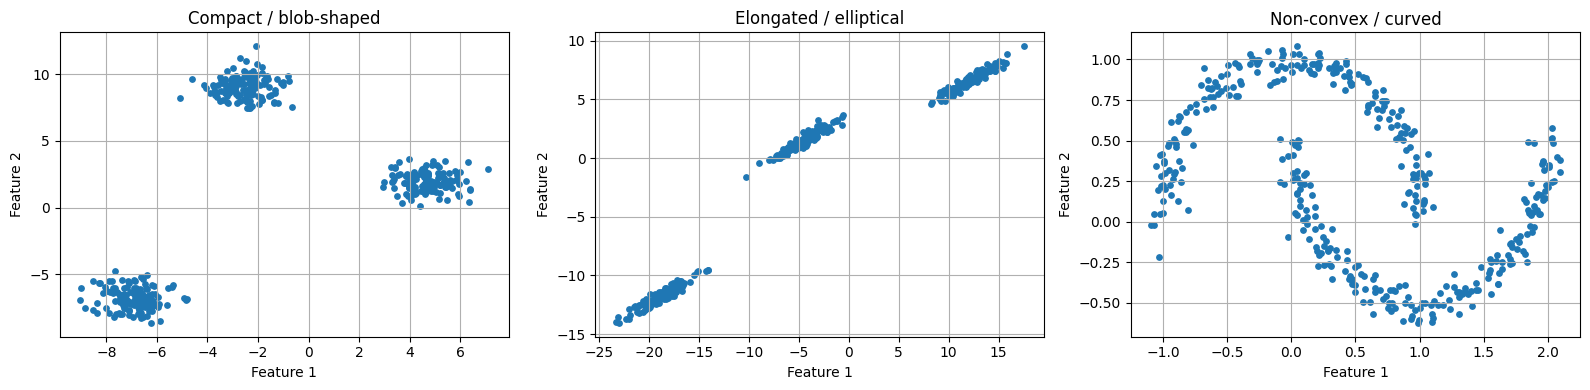

In [56]:
# Compare three different cluster geometries

X_blob_demo, _ = make_blobs(
    n_samples=400,
    centers=3,
    cluster_std=0.8,
    random_state=RANDOM_STATE
)

X_moon_demo, _ = make_moons(
    n_samples=400,
    noise=0.06,
    random_state=RANDOM_STATE
)

# Create an elongated cluster dataset using a linear transformation.
X_elongated, _ = make_blobs(
    n_samples=400,
    centers=3,
    cluster_std=0.7,
    random_state=RANDOM_STATE
)
stretch = np.array([[2.5, 1.2], [0.2, 0.5]])
X_elongated = X_elongated @ stretch

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(X_blob_demo[:, 0], X_blob_demo[:, 1], s=15)
axes[0].set_title("Compact / blob-shaped")

axes[1].scatter(X_elongated[:, 0], X_elongated[:, 1], s=15)
axes[1].set_title("Elongated / elliptical")

axes[2].scatter(X_moon_demo[:, 0], X_moon_demo[:, 1], s=15)
axes[2].set_title("Non-convex / curved")

for ax in axes:
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()


# 5. Agglomerative Clustering — Go Deeper

Agglomerative clustering is useful when you want to think about clustering as a **sequence of merges** rather than one final partition.

Imagine five observations:

`A  B  C  D  E`

The algorithm might first merge:

`(A,B)`

then:

`(A,B,C)`

and later:

`(A,B,C,D,E)`

The sequence can be represented by a **dendrogram**.

### Why this matters

A dendrogram lets you inspect the hierarchy at different levels instead of deciding that there is only one "correct" number of clusters.

### Example use cases
- Document/topic grouping
- Customer segmentation
- Gene-expression analysis
- Taxonomies and hierarchical organization

### Limitation
The algorithm can become expensive as the number of observations grows, so it is often more practical for small-to-medium datasets.


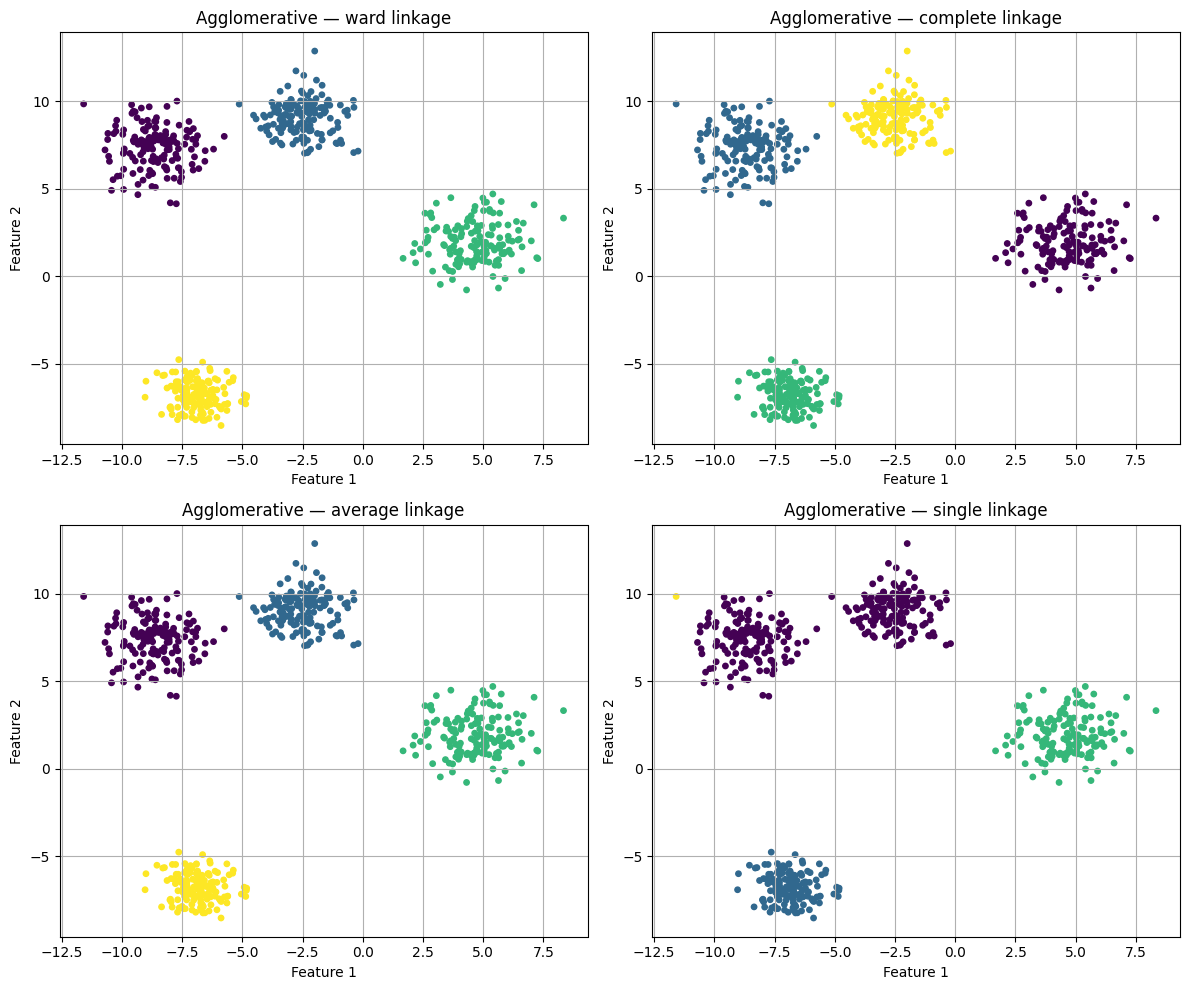

In [57]:
# Try different linkage strategies on the same dataset

linkages = ["ward", "complete", "average", "single"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, linkage in zip(axes.ravel(), linkages):
    model = AgglomerativeClustering(
        n_clusters=4,
        linkage=linkage
    )
    labels = model.fit_predict(X)

    ax.scatter(X[:, 0], X[:, 1], c=labels, s=15)
    ax.set_title(f"Agglomerative — {linkage} linkage")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()


# 6. BIRCH — What Is the CF Tree Doing?

BIRCH is particularly interesting because it does not need to repeatedly keep all original observations in the same form.

A **Clustering Feature (CF)** summarizes a group using compact statistics.

Conceptually, a CF contains information such as:

- number of observations,
- linear sum,
- squared sum.

These summaries can be organized into a **CF tree**.

### Intuition

Instead of carrying around:

`10,000 individual points`

we can first create compact summaries such as:

`CF1, CF2, CF3, ...`

and cluster those summaries.

### When this is useful

Think of:
- millions of customer records,
- large sensor datasets,
- large-scale log data.

BIRCH is primarily valuable because of **scalability**, not because it discovers a radically different definition of a cluster.


# 7. Mean-Shift — Think in Terms of Density

Mean-Shift asks:

> Where is the local density highest?

Imagine placing a small window around a point. The algorithm calculates the local mean and shifts the window toward that mean. Repeating this process moves the window toward a **mode / density peak**.

### Important parameter: bandwidth

Bandwidth controls the size of the neighborhood.

- **Small bandwidth:** many small density peaks may be discovered.
- **Large bandwidth:** nearby peaks may merge into fewer clusters.

So although Mean-Shift does not require you to specify `n_clusters`, it still has an important parameter controlling the result.


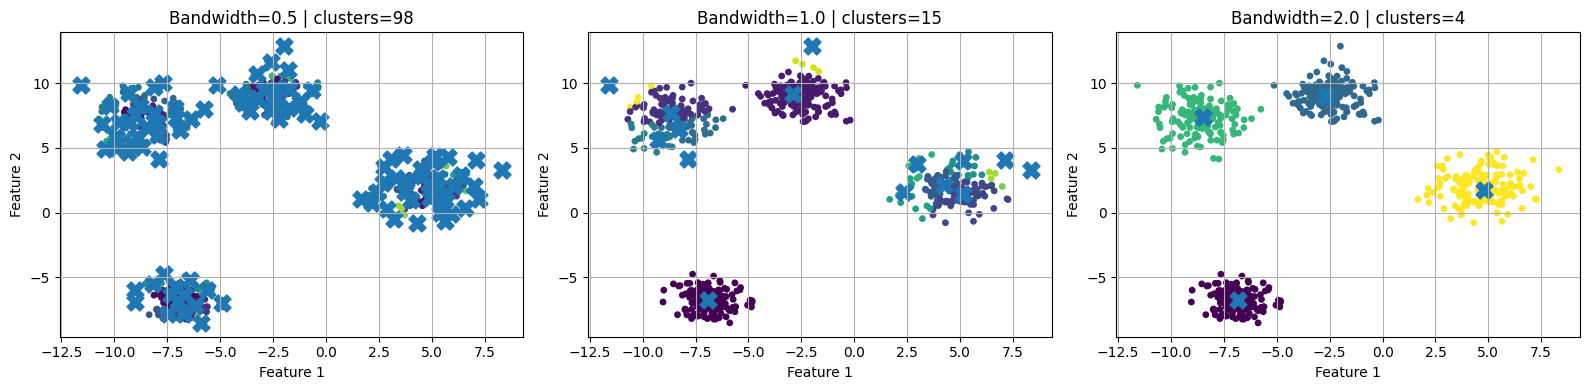

In [58]:
# Demonstrate Mean-Shift sensitivity to bandwidth

bandwidths = [0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, bandwidth in zip(axes, bandwidths):
    model = MeanShift(bandwidth=bandwidth)
    labels = model.fit_predict(X)

    ax.scatter(X[:, 0], X[:, 1], c=labels, s=15)
    ax.scatter(
        model.cluster_centers_[:, 0],
        model.cluster_centers_[:, 1],
        marker="X",
        s=150
    )
    ax.set_title(
        f"Bandwidth={bandwidth} | "
        f"clusters={len(np.unique(labels))}"
    )
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()


# 8. Spectral Clustering — Graph Intuition

Spectral Clustering changes the question.

Instead of:

> "Which centroid is this point closest to?"

it is closer to:

> "Which observations are strongly connected to each other?"

A graph can be created where:
- each observation is a node,
- nearby observations are connected by edges.

This makes Spectral Clustering powerful for **non-convex structures**.

### Example

For two moons, points along the same curved moon are strongly connected through local neighborhoods even though their Euclidean distance may not fit a simple spherical cluster model.


# 9. Gaussian Mixture Models — A Probabilistic View

A GMM models the data as:

**Gaussian component 1 + Gaussian component 2 + ... + Gaussian component K**

Each component has:

- a **mean** → where it is centered,
- a **covariance** → how it spreads and rotates,
- a **weight** → how much of the population it represents.

This makes GMM different from K-Means.

### K-Means

A point is assigned to the nearest centroid.

### GMM

A point can have partial membership in multiple components.

For example:

```text
Customer A
Component 0: 0.05
Component 1: 0.85
Component 2: 0.10
```

This is valuable when cluster boundaries are not sharp.


# 10. Covariance Types — Visual Intuition

The covariance structure determines what shapes a Gaussian component can represent.

### `spherical`

One variance value per component.

Think:

**circles / spheres**

### `diag`

Separate variance along each feature axis, but no feature-to-feature covariance.

Think:

**axis-aligned ellipses**

### `tied`

All components share one covariance matrix.

Think:

**same general shape, different centers**

### `full`

Every component gets its own covariance matrix.

Think:

**different rotated ellipses are allowed**

### Trade-off

`full` is the most flexible of these choices, but it also has the most parameters and can be more prone to overfitting, especially with limited data.


In [59]:
# Compare covariance assumptions on deliberately elongated data

gmm_cov_results = []

for cov_type in covariance_types:
    model = GaussianMixture(
        n_components=3,
        covariance_type=cov_type,
        random_state=RANDOM_STATE
    )
    model.fit(X_elongated)

    gmm_cov_results.append({
        "covariance_type": cov_type,
        "AIC": model.aic(X_elongated),
        "BIC": model.bic(X_elongated),
        "converged": model.converged_,
        "iterations": model.n_iter_
    })

pd.DataFrame(gmm_cov_results)


,covariance_type,AIC,BIC,converged,iterations
0,full,2585.898191,2653.753088,True,2
1,tied,2577.124451,2621.030561,True,2
2,diag,3513.442002,3569.322506,True,2
3,spherical,3672.788280,3716.694390,True,2


# 11. GMM and the EM Algorithm — Step by Step

The Expectation-Maximization idea can be understood as a repeated two-step conversation between the model and the data.

### Step 1 — Initialize

Start with estimates for:
- means,
- covariances,
- mixture weights.

### Step 2 — E-step

For every point, estimate:

> "How much responsibility does each Gaussian component take for explaining this point?"

These are often called **responsibilities**.

### Step 3 — M-step

Use those responsibilities to update:
- means,
- covariances,
- weights.

### Step 4 — Repeat

Continue until the model converges or reaches the iteration limit.

This is why GMM is not simply "K-Means with probabilities": it is fitting a probabilistic distribution.


In [60]:
# Inspect EM convergence information

em_model = GaussianMixture(
    n_components=4,
    covariance_type="full",
    max_iter=200,
    random_state=RANDOM_STATE
)

em_model.fit(X)

print("Converged:", em_model.converged_)
print("Iterations:", em_model.n_iter_)
print("Lower bound:", em_model.lower_bound_)


Converged: True
Iterations: 2
Lower bound: -4.210163448068948


# 12. GMM Decision Boundary and Uncertainty

The most interesting points are often not the points deep inside a cluster.

Points near the overlap between Gaussian components can have probabilities such as:

`Component A = 0.52`  
`Component B = 0.46`

These are **ambiguous observations**.

In a business setting, this can be useful:

- Customer clearly in segment A → high confidence.
- Customer between A and B → transition/ambiguous segment.
- Sensor reading with low overall density → potentially unusual observation.

Soft clustering therefore provides information that a simple cluster label cannot provide.


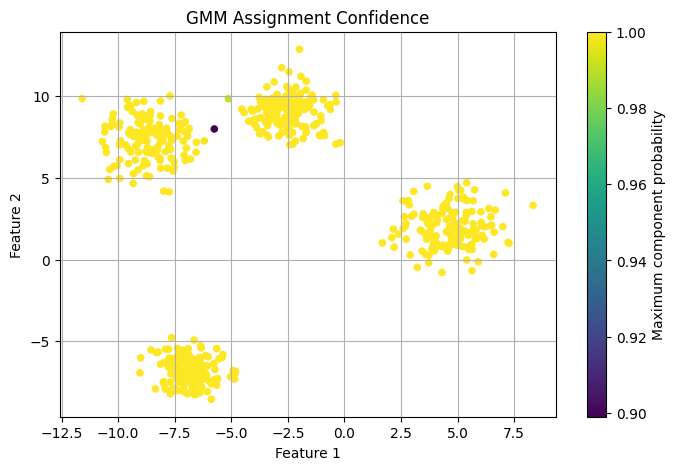

In [61]:
# Plot observations by their confidence

confidence = proba.max(axis=1)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=confidence,
    s=20
)
plt.colorbar(label="Maximum component probability")
plt.title("GMM Assignment Confidence")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


Algorithm Selection Idea

| Data situation | Good starting point | Why |
|---|---|---|
| Compact spherical groups | K-Means | Fast and simple |
| Need hierarchy | Agglomerative | Produces nested grouping structure |
| Huge dataset | BIRCH | Designed for scalability |
| Density peaks matter | Mean-Shift | Finds modes of density |
| Curved/non-convex groups | Spectral | Uses graph connectivity |
| Overlapping groups | GMM | Soft probabilistic membership |
| Elliptical clusters | GMM | Covariance models shape |
| Need density estimate | GMM | Explicit probability model |

